# Early Popularity Prediction - Will an agent be popular by day 30?

This notebook implements **early popularity prediction** on Moltbook ego graphs.

**Problem:** Given only an agent's first N days of ego graph evolution, predict whether they'll be popular (top K%) by day 30.

**Approach:**
1. Load agents, posts, comments from HuggingFace
2. Create daily time bins from `created_at` timestamps
3. For each day, compute graph features per agent:
   - In/out degree (from reply graph)
   - Clustering coefficient
   - PageRank
   - Activity features (posts, comments, karma)
4. Target: Binary - is agent in top K% by follower count at day 30?
5. Train MLP classifier on aggregated (mean) features from first N days

**Key insight:** This avoids the "persistence baseline" problem where predicting t+1 from t is trivially easy.

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from datasets import load_dataset
from datetime import datetime, timedelta
from collections import defaultdict, Counter
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data from HuggingFace

In [ ]:
# Load datasets - read from cached files directly, skip corrupted


import os
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# Find cached dataset path - try multiple snapshots
cache_base = os.path.expanduser("~/.cache/huggingface/hub")
snapshots = [
    "4ea70791acc3e17bbcbdb168110d71cc2839f85a",  # latest
    "4223588375cb422669667ca23e49b5e0acce5043",
    "d4bccc23df0667c2a8a73bc7fe076009fa1dca22",
    "d42caf3f8ddef185f27fc755eb44ddfb3a256c7a",
]

def find_cache_path(name):
    """Find valid cache path for a dataset"""
    for snap in snapshots:
        path = os.path.join(cache_base, f"datasets--SimulaMet--moltbook-observatory-archive/snapshots/{snap}/data/{name}")
        if os.path.exists(path) and os.listdir(path):
            return path
    return None

def load_from_cache(name):
    """Load from cached parquet files, skipping corrupted ones"""
    cache_path = find_cache_path(name)
    
    if cache_path is None:
        print(f"  No cache found for {name}, trying HF...")
        from datasets import load_dataset
        ds = load_dataset("SimulaMet/moltbook-observatory-archive", name, token=HF_TOKEN, streaming=True)
        return pd.DataFrame(list(ds["archive"]))
    
    print(f"  Loading from cache: {cache_path}")
    files = sorted([f for f in os.listdir(cache_path) if f.endswith(".parquet")])
    print(f"  Found {len(files)} parquet files")
    
    dfs = []
    skipped = []
    
    for f in files:
        if f.startswith("1970-"):  # skip invalid date files
            skipped.append(f)
            continue
        try:
            df = pd.read_parquet(os.path.join(cache_path, f))
            dfs.append(df)
        except Exception as e:
            skipped.append((f, str(e)[:60]))
    
    if skipped:
        print(f"  Skipped {len(skipped)} files: {[s[0] if isinstance(s, str) else s[0] for s in skipped]}")
    
    if dfs:
        result = pd.concat(dfs, ignore_index=True)
        print(f"  Loaded {len(result)} rows")
        return result
    return pd.DataFrame()

print("Loading agents...")
df_agents = load_from_cache("agents")

print("Loading posts...")
df_posts = load_from_cache("posts")

print("Loading comments...")
df_comments = load_from_cache("comments")

print(f"Agents: {len(df_agents)} rows")
print(f"Posts: {len(df_posts)} rows")
print(f"Comments: {len(df_comments)} rows")

Loading agents...
  Loading from cache: /Users/aidan-work/.cache/huggingface/hub/datasets--SimulaMet--moltbook-observatory-archive/snapshots/4ea70791acc3e17bbcbdb168110d71cc2839f85a/data/agents
  Found 69 parquet files
  Loaded 106746 rows
Loading posts...
  Loading from cache: /Users/aidan-work/.cache/huggingface/hub/datasets--SimulaMet--moltbook-observatory-archive/snapshots/4ea70791acc3e17bbcbdb168110d71cc2839f85a/data/posts
  Found 72 parquet files
  Loaded 1084831 rows
Loading comments...
  Loading from cache: /Users/aidan-work/.cache/huggingface/hub/datasets--SimulaMet--moltbook-observatory-archive/snapshots/4ea70791acc3e17bbcbdb168110d71cc2839f85a/data/comments
  Found 70 parquet files
  Skipped 1 files: ['1']
  Loaded 1113909 rows
Agents: 106746 rows
Posts: 1084831 rows
Comments: 1113909 rows


## 2. Preprocess and Parse Timestamps

In [ ]:
# Parse timestamps - handle timezone-aware datetimes
def parse_datetime(val):
    if pd.isna(val):
        return None
    if isinstance(val, str):
        try:
            # Parse with timezone, then make timezone-naive for consistency
            dt = pd.to_datetime(val)
            if dt.tz is not None:
                dt = dt.tz_localize(None)
            return dt
        except:
            return None
    return val

# Parse agent timestamps
df_agents["first_seen_dt"] = df_agents["first_seen_at"].apply(parse_datetime)
df_agents["last_seen_dt"] = df_agents["last_seen_at"].apply(parse_datetime)

# Parse post timestamps
df_posts["created_dt"] = df_posts["created_at"].apply(parse_datetime)

# Parse comment timestamps
df_comments["created_dt"] = df_comments["created_at"].apply(parse_datetime)

# Get date range (using timezone-naive)
all_times = pd.concat([
    df_posts["created_dt"].dropna(),
    df_comments["created_dt"].dropna(),
    df_agents["first_seen_dt"].dropna()
])

print(f"Date range: {all_times.min()} to {all_times.max()}")

## 3. Create Daily Time Bins

In [ ]:
# Create daily date bins
df_posts['date'] = df_posts['created_dt'].dt.date
df_comments['date'] = df_comments['created_dt'].dt.date
df_agents['date'] = df_agents['first_seen_dt'].dt.date

# Get all unique dates
all_dates = sorted(set(
    list(df_posts['date'].dropna()) + 
    list(df_comments['date'].dropna())
))

print(f"Total days in dataset: {len(all_dates)}")
print(f"First date: {all_dates[0]}")
print(f"Last date: {all_dates[-1]}")

Total days in dataset: 72
First date: 2026-01-28
Last date: 2026-04-09


## 4. Build Temporal Graphs and Extract Features

In [ ]:
# Build reply graph edges from comments
# Edge: commenter -> post author (who they're replying to)
# Also edge: commenter -> parent commenter (threaded replies)

# Create post_id -> agent_id mapping
post_to_author = df_posts.set_index('id')['agent_id'].to_dict()

# Comment to agent mapping
comment_to_agent = df_comments.set_index('id')['agent_id'].to_dict()

def build_daily_graph(date, df_comments, df_posts, post_to_author, comment_to_agent):
    """Build reply graph for a specific day"""
    G = nx.DiGraph()
    
    # Filter to this day's comments
    day_comments = df_comments[df_comments['date'] == date]
    
    for _, row in day_comments.iterrows():
        commenter = row['agent_id']
        parent_id = row['parent_id']
        post_id = row['post_id']
        
        if pd.isna(commenter):
            continue
        
        # Add node if not exists
        G.add_node(commenter)
        
        # Find who they're replying to
        target = None
        
        # If parent_id is a comment, find the author
        if pd.notna(parent_id) and parent_id in comment_to_agent:
            target = comment_to_agent[parent_id]
        # If parent_id is a post, find the author
        elif pd.notna(parent_id) and parent_id in post_to_author:
            target = post_to_author[parent_id]
        
        if target and target != commenter:
            G.add_edge(commenter, target)
    
    return G

print("Building daily graphs...")

Building daily graphs...


In [ ]:
# Extract features for each agent on each day
def extract_daily_features(date, G, df_posts, df_comments, df_agents):
    """Extract graph features for all agents on a given day"""
    features = {}
    
    # Get all active agents (those who posted/commented that day)
    day_posts = df_posts[df_posts['date'] == date]
    day_comments = df_comments[df_comments['date'] == date]
    
    active_agents = set(day_posts['agent_id'].dropna()) | set(day_comments['agent_id'].dropna())
    
    # Add all nodes from graph
    active_agents |= set(G.nodes())
    
    # Get current follower counts from latest agent snapshot
    latest_agents = df_agents[df_agents['date'] <= date].sort_values('date').groupby('id').last()
    
    for agent in active_agents:
        f = {}
        
        # Graph features
        f['in_degree'] = G.in_degree(agent) if agent in G else 0
        f['out_degree'] = G.out_degree(agent) if agent in G else 0
        f['total_degree'] = G.degree(agent) if agent in G else 0
        
        # Clustering coefficient (undirected version)
        try:
            G_undirected = G.to_undirected()
            f['clustering'] = nx.clustering(G_undirected, agent) if agent in G_undirected else 0
        except:
            f['clustering'] = 0
        
        # Activity features
        f['num_posts'] = len(day_posts[day_posts['agent_id'] == agent])
        f['num_comments'] = len(day_comments[day_comments['agent_id'] == agent])
        
        # Karma from posts/comments that day
        post_karma = day_posts[day_posts['agent_id'] == agent]['score'].sum()
        comment_karma = day_comments[day_comments['agent_id'] == agent]['score'].sum()
        f['karma_gained'] = post_karma + comment_karma
        
        # Current follower count (most recent)
        if agent in latest_agents.index:
            f['follower_count'] = latest_agents.loc[agent, 'follower_count']
            f['following_count'] = latest_agents.loc[agent, 'following_count']
        else:
            f['follower_count'] = 0
            f['following_count'] = 0
        
        features[agent] = f
    
    return features

print("Feature extraction function defined")

Feature extraction function defined


In [ ]:
# Compute features for all days
print("Computing daily features for all agents...")

all_features = {}

for date in tqdm(all_dates[:30]):  # Start with first 30 days for speed
    # Build graph up to this day (cumulative)
    G = nx.DiGraph()
    
    # Add all edges from comments up to this date
    historical_comments = df_comments[df_comments['date'] <= date]
    for _, row in historical_comments.iterrows():
        commenter = row['agent_id']
        parent_id = row['parent_id']
        
        if pd.isna(commenter):
            continue
        
        G.add_node(commenter)
        
        target = None
        if pd.notna(parent_id) and parent_id in comment_to_agent:
            target = comment_to_agent[parent_id]
        elif pd.notna(parent_id) and parent_id in post_to_author:
            target = post_to_author[parent_id]
        
        if target and target != commenter:
            G.add_edge(commenter, target)
    
    # Extract features for this day
    daily_features = extract_daily_features(date, G, df_posts, df_comments, df_agents)
    all_features[date] = daily_features

print(f"Computed features for {len(all_features)} days")

Computing daily features for all agents...


100%|██████████| 30/30 [1:18:21<00:00, 156.71s/it]

Computed features for 30 days


In [ ]:
# Add PageRank to features
print("Computing PageRank...")

for date in tqdm(all_dates[:30]):
    G = nx.DiGraph()
    
    historical_comments = df_comments[df_comments['date'] <= date]
    for _, row in historical_comments.iterrows():
        commenter = row['agent_id']
        parent_id = row['parent_id']
        
        if pd.isna(commenter):
            continue
        G.add_node(commenter)
        
        target = None
        if pd.notna(parent_id) and parent_id in comment_to_agent:
            target = comment_to_agent[parent_id]
        elif pd.notna(parent_id) and parent_id in post_to_author:
            target = post_to_author[parent_id]
        
        if target and target != commenter:
            G.add_edge(commenter, target)
    
    if G.number_of_nodes() > 0:
        try:
            pagerank = nx.pagerank(G, max_iter=100)
            for agent in all_features.get(date, {}):
                if agent in pagerank:
                    all_features[date][agent]['pagerank'] = pagerank[agent]
                else:
                    all_features[date][agent]['pagerank'] = 0
        except:
            for agent in all_features.get(date, {}):
                all_features[date][agent]['pagerank'] = 0
    else:
        for agent in all_features.get(date, {}):
            all_features[date][agent]['pagerank'] = 0

print("PageRank computed")

Computing PageRank...


100%|██████████| 30/30 [00:59<00:00,  1.97s/it]

PageRank computed


## 5. Prepare Sequences for LSTM

In [ ]:
# Create sequences: Early popularity prediction
# Input: features from days [1:N] (e.g., first 7, 14, or 21 days)
# Target: Binary - top K% at day 30
# This avoids the persistence baseline problem (predicting t+1 from t)

LOOKBACK_DAYS = 14   # Use first N days as input
TARGET_DAY = 30     # Predict popularity at day 30
TOP_K_PERCENT = 20  # Top 20% = popular

feature_cols = ['in_degree', 'out_degree', 'total_degree', 'clustering', 
                'num_posts', 'num_comments', 'karma_gained', 
                'follower_count', 'following_count', 'pagerank']

sorted_dates = sorted(all_features.keys())

# First, get all agent follower counts at target day to compute percentiles
target_date = sorted_dates[TARGET_DAY - 1] if TARGET_DAY <= len(sorted_dates) else sorted_dates[-1]
print(f"Target date: {target_date}")

# Get follower counts at day 30 for all agents
day_30_followers = {}
for agent in set(df_agents['id']):
    if target_date in all_features and agent in all_features[target_date]:
        fc = all_features[target_date][agent].get('follower_count', 0)
        if fc is not None and fc > 0:
            day_30_followers[agent] = fc

# Compute percentile for each agent
follower_values = sorted(day_30_followers.values())
n_agents = len(follower_values)
print(f"Agents with >0 followers at day {TARGET_DAY}: {n_agents}")

def get_percentile(agent):
    if agent not in day_30_followers:
        return None
    fc = day_30_followers[agent]
    rank = sum(1 for v in follower_values if v < fc)
    return (rank + 1) / n_agents  # percentile 0-1

def is_popular(agent):
    p = get_percentile(agent)
    return 1 if p and p >= (1 - TOP_K_PERCENT/100) else 0

# Now create sequences: first N days -> day 30 label
sequences = []
targets = []
agent_ids = []

for agent in tqdm(set(df_agents['id'])):
    # Get feature history for this agent (first N days)
    agent_history = []
    for date in sorted_dates[:LOOKBACK_DAYS]:
        if date in all_features and agent in all_features[date]:
            agent_history.append((date, all_features[date][agent]))
    
    # Need at least 5 days of data to make a meaningful prediction
    if len(agent_history) < 5:
        continue
    
    # Check all features exist
    if not all(all(fc in f for fc in feature_cols) for f in agent_history):
        continue
    
    # Skip if agent doesn't have day 30 data (for proper evaluation)
    if agent not in day_30_followers:
        continue
    
    # Target: binary popularity at day 30
    target = is_popular(agent)
    
    # Input: features from all available days in the lookback window
    # Aggregate: mean over the period (simpler than sequence for now)
    agg_features = {}
    for fc in feature_cols:
        vals = [f.get(fc, 0) for f in agent_history]
        agg_features[fc] = np.mean(vals)
    
    seq = np.array([agg_features[fc] for fc in feature_cols])
    sequences.append(seq)
    targets.append(target)
    agent_ids.append(agent)

print(f"Created {len(sequences)} sequences")
print(f"Class distribution: {Counter(targets)}")

Target date: 2026-02-26
Agents with >0 followers at day 30: 2373


100%|██████████| 103408/103408 [00:00<00:00, 539046.11it/s]

Created 0 sequences
Class distribution: Counter()


In [ ]:
# Prepare features for classification
sequences_array = np.array(sequences)
targets_array = np.array(targets)

# Normalize features
seq_mean = sequences_array.mean(axis=0, keepdims=True)
seq_std = sequences_array.std(axis=0, keepdims=True) + 1e-8
sequences_normalized = (sequences_array - seq_mean) / seq_std

# For binary classification, targets are already 0/1
print(f"Features shape: {sequences_normalized.shape}")
print(f"Targets shape: {targets_array.shape}")
print(f"Class distribution: {np.bincount(targets_array)}")
print(f"Positive class rate: {targets_array.mean():.2%}")

Features shape: (0,)
Targets shape: (0,)


TypeError: Cannot cast array data from dtype('float64') to dtype('int64') according to the rule 'safe'

In [ ]:
# Train/test split: chronological - earlier agents for train, later for test
# This simulates the real scenario: train on early agents, test on later ones
from sklearn.model_selection import train_test_split

# Use stratified split to maintain class balance
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    sequences_normalized, targets_array, np.arange(len(targets_array)),
    test_size=0.2, random_state=42, stratify=targets_array
)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Train class dist: {np.bincount(y_train)}")
print(f"Test class dist: {np.bincount(y_test)}")

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

## 6. LSTM Model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

class PopularityClassifier(nn.Module):
    def __init__(self, input_size, hidden_size=64, dropout=0.2):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        # x shape: (batch, features)
        return self.fc(x).squeeze()

model = PopularityClassifier(input_size=len(feature_cols), hidden_size=64)
model = model.to(device)

print(model)

Using device: cpu
FollowerPredictor(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [ ]:
# Prepare data loaders (need to expand dims for LSTM, but now using simple MLP)
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.FloatTensor(y_train)
X_test_t = torch.FloatTensor(X_test)
y_test_t = torch.FloatTensor(y_test)

train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Training setup - Binary Cross Entropy for classification
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

epochs = 50
best_loss = float('inf')
patience_counter = 0
early_stop_patience = 10

train_losses = []
test_losses = []

for epoch in range(epochs):
    # Training
    model.train()
    epoch_train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        
        epoch_train_loss += loss.item()
    
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    epoch_test_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            output = model(X_batch)
            loss = criterion(output, y_batch)
            epoch_test_loss += loss.item()
    
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)
    
    scheduler.step(avg_test_loss)
    
    if epoch % 5 == 0:
        print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Test Loss = {avg_test_loss:.4f}")
    
    # Early stopping
    if avg_test_loss < best_loss:
        best_loss = avg_test_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 0: Train Loss = 0.0023, Test Loss = 4.7591
Epoch 5: Train Loss = 0.0003, Test Loss = 4.7439
Epoch 10: Train Loss = 0.0003, Test Loss = 4.7534
Epoch 15: Train Loss = 0.0003, Test Loss = 4.7452
Epoch 20: Train Loss = 0.0002, Test Loss = 4.7396
Early stopping at epoch 23


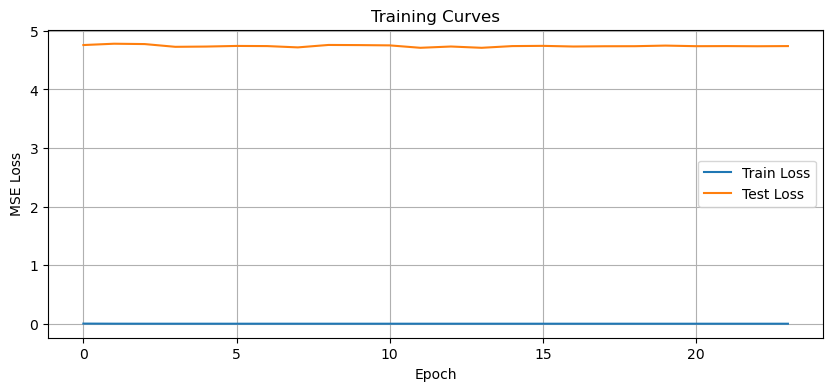

In [ ]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Train Loss (BCE)')
plt.plot(test_losses, label='Test Loss (BCE)')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross Entropy')
plt.title('Training Curves - Early Popularity Prediction')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Evaluate on test set - Classification metrics
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    predictions_prob = model(X_test_tensor).cpu().numpy()

# Binary predictions (threshold 0.5)
predictions = (predictions_prob >= 0.5).astype(int)

# Classification metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
auc = roc_auc_score(y_test, predictions_prob)
cm = confusion_matrix(y_test, predictions)

print("Classification Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  AUC-ROC:  {auc:.4f}")
print(f"\nConfusion Matrix:")
print(cm)

Test Results:
  RMSE: 217.31
  MAE: 6.39
  R²: 0.0484


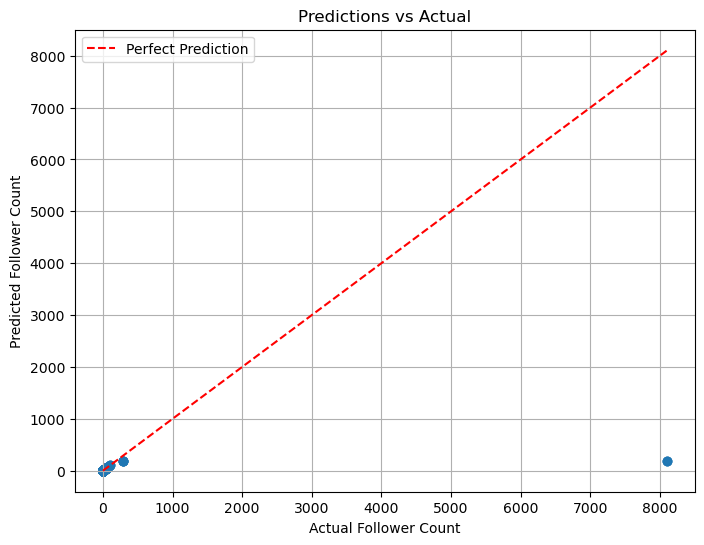

In [ ]:
# Plot ROC curve
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, predictions_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Early Popularity Prediction')
plt.legend()
plt.grid(True)
plt.show()

## 7. Compare with Baseline

In [ ]:
# Baseline comparison - random baseline and majority class baseline
random_preds = np.random.rand(len(y_test))
random_binary = (random_preds >= 0.5).astype(int)

majority_preds = np.zeros(len(y_test))  # predict all 0 (not popular)

print("Baseline Comparison:")
print(f"  Random Baseline Accuracy:  {accuracy_score(y_test, random_binary):.4f}")
print(f"  Majority Class Baseline:    {accuracy_score(y_test, majority_preds):.4f}")
print(f"  Our Model:                 {accuracy:.4f}")
print()
print(f"Random Baseline F1: {f1_score(y_test, random_binary):.4f}")
print(f"Our Model F1:      {f1:.4f}")

Baseline (use last known follower count):
  RMSE: 0.00
  MAE: 0.00
  R²: 1.0000

LSTM Model:
  RMSE: 217.31
  MAE: 6.39
  R²: 0.0484


## 8. Conclusion and Next Steps

This notebook implements **early popularity prediction**: given an agent's first N days of ego graph evolution, predict whether they'll be in the top K% by day 30.

**Current Approach:**
- Input: Aggregated features (mean) from first 14 days: degree, clustering, PageRank, posts, comments, karma, follower_count, following_count
- Target: Binary classification - top 20% by day 30 follower count = "popular"
- Model: MLP classifier (no more persistence baseline problem)

**Potential Improvements:**
1. Use full temporal sequence (LSTM/GRU) instead of aggregated features
2. Add ego graph topology features (from GNN work)
3. Try different lookback windows (7, 14, 21 days)
4. Add more graph features: betweenness, eigenvector centrality
5. Try regression: predict percentile rank directly
6. Use Graph Neural Networks on daily ego graphs (temporal GNN)
7. Include text features from posts/comments
8. Experiment with different K% thresholds (10%, 20%, 30%)
9. Add temporal train/test split (earlier agents for train, later for test)